In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [5]:
df = pd.read_csv(r'diabetes.csv')
df.head()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [6]:
df.isnull().sum()
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [7]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [8]:
cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
df[cols] = df[cols].replace(0, np.nan)

In [9]:
df.isnull().sum()

Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

Text(0.5, 1.0, 'heatmap korelasi')

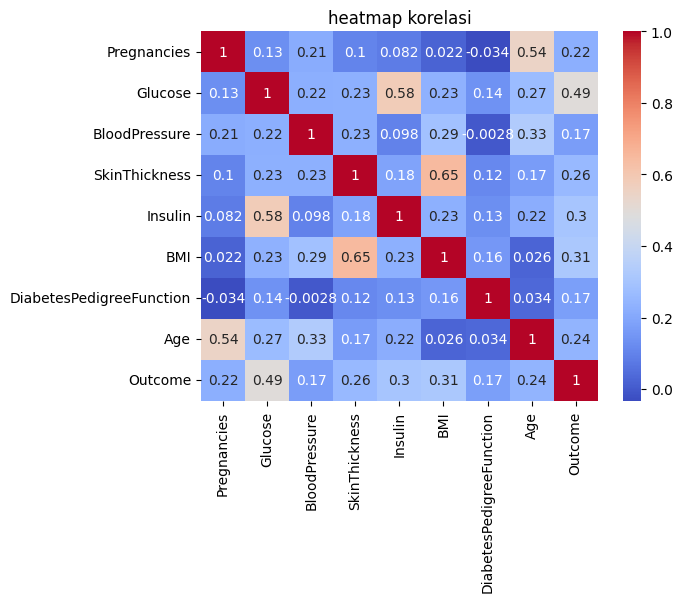

In [10]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('heatmap korelasi')

Text(0.5, 1.0, 'boxplot semua fitur')

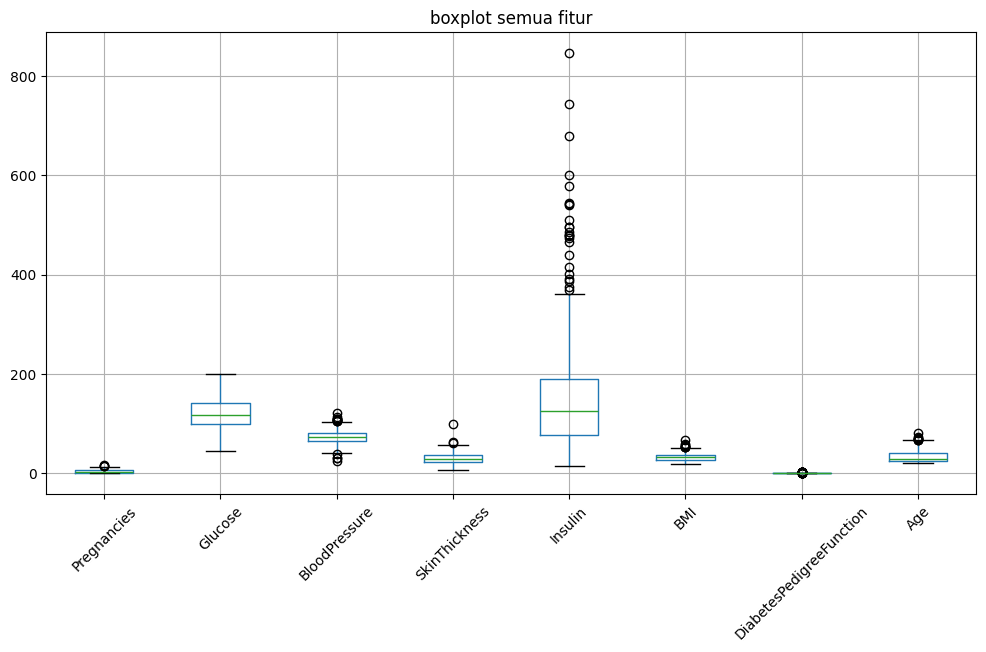

In [11]:
df.drop(columns=['Outcome']).boxplot(figsize=(12, 6))
plt.xticks(rotation=45)
plt.title('boxplot semua fitur')

In [12]:
Q1 = df['Insulin'].quantile(0.25)
Q3 = df['Insulin'].quantile(0.75)

IQR = Q3 - Q1
batas_atas = Q3 + 1.5 * IQR

outlier = df[df['Insulin'] > batas_atas]
print(f'Outlier Insulin: {len(outlier)} dari  {len(df)} ({len(outlier)/len(df)*100:1f}%)')

Outlier Insulin: 24 dari  768 (3.125000%)


In [13]:
df.isnull().sum()

Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

In [14]:
df.dtypes

Pregnancies                   int64
Glucose                     float64
BloodPressure               float64
SkinThickness               float64
Insulin                     float64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

In [15]:
df.duplicated().sum

<bound method Series.sum of 0      False
1      False
2      False
3      False
4      False
       ...  
763    False
764    False
765    False
766    False
767    False
Length: 768, dtype: bool>

In [16]:
cols_missing = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
print(df[cols_missing].skew())

Glucose          0.530989
BloodPressure    0.134153
SkinThickness    0.690619
Insulin          2.166464
BMI              0.593970
dtype: float64


In [17]:
df['Glucose'] = df['Glucose'].fillna(df['Glucose'].median())
df['BloodPressure'] = df['BloodPressure'].fillna(df['BloodPressure'].mean())
df['SkinThickness'] = df['SkinThickness'].fillna(df['SkinThickness'].median())
df['Insulin'] = df['Insulin'].fillna(df['Insulin'].median())
df['BMI'] = df['BMI'].fillna(df['BMI'].median())

In [18]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [19]:
df.dtypes

Pregnancies                   int64
Glucose                     float64
BloodPressure               float64
SkinThickness               float64
Insulin                     float64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

In [20]:
# normalisasi semua kolom kecuali target (Outcome diabetes)
for col in df.columns:
    if col != 'Outcome':
        df[col] = (df[col]- df[col].min()) / (df[col].max() - df[col].min())

x = df.drop(columns=['Outcome'])
y = df['Outcome']

split = int(0.8 * len(df))
x_train = x.iloc[:split].values
x_test = x.iloc[split:].values
y_train = y.iloc[:split].values
y_test = y.iloc[split:].values

print(f'Train: {len(x_train)} data')
print(f'Test: {len(x_test)} data')
df.head()

Train: 614 data
Test: 154 data


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,0.352941,0.670968,0.489796,0.304348,0.133413,0.314928,0.234415,0.483333,1
1,0.058824,0.264516,0.428571,0.239130,0.133413,0.171779,0.116567,0.166667,0
2,0.470588,0.896774,0.408163,0.239130,0.133413,0.104294,0.253629,0.183333,1
3,0.058824,0.290323,0.428571,0.173913,0.096154,0.202454,0.038002,0.000000,0
4,0.000000,0.600000,0.163265,0.304348,0.185096,0.509202,0.943638,0.200000,1


In [26]:
#function gain 
def gini(y):
    if len(y) == 0:
        return 0
    p1 = np.sum(y == 1) / len(y)
    p0 = np.sum(y == 0) / len(y)
    return 1 - (p1**2 + p0**2)

def best_split(x, y):
    best_gain = -1
    best_col = None
    best_val = None
    gini_parent = gini(y)
    for col in range(x.shape[1]):
        for val in np.unique(x[:, col]):
            kiri = y[x[:, col] <= val]
            kanan = y[x[:, col] > val]
            if len(kiri) == 0 or len(kanan) == 0:
                continue
            gini_child = (len(kiri)*gini(kiri) + len(kanan)*gini(kanan)) / len(y)
            gain = gini_parent - gini_child
            if gain > best_gain:
                best_gain = gain
                best_col = col
                best_val = val
    return best_col, best_val, best_gain
        
class Node:
    def __init__(self):
        self.col = None
        self.val = None
        self.kiri = None
        self.kanan = None
        self.label = None

def build_tree(x, y, depth=0, max_depth=5):
    if len(np.unique(y)) == 1:
        node = Node()
        node.label = y[0]
        return node
    if depth == max_depth:
        node = Node()
        node.label = np.bincount(y).argmax()
        return node
    col, val, gain = best_split(x, y)
    if gain == 0:
        node = Node()
        node.label = np.bincount(y).argmax()
        return node
    kiri_mask = x[:, col] <= val
    kanan_mask = x[:, col] > val
    node = Node()
    node.col = col
    node.val = val
    node.kiri = build_tree(x[kiri_mask], y[kiri_mask], depth+1, max_depth)
    node.kanan = build_tree(x[kanan_mask], y[kanan_mask], depth+1, max_depth)
    return node

def predict_satu(node, x):
    if node.label is not None:
        return node.label
    if x[node.col] <= node.val:
        return predict_satu(node.kiri, x)
    else:
        return predict_satu(node.kanan, x)
    
def predict(node, x):
    return np.array([predict_satu(node, x) for x in x])

# evaluasi model
tree = build_tree(x_train, y_train)
y_pred = predict(tree, x_test)

akurasi = np.sum(y_pred == y_test) / len(y_test) * 100
TP = np.sum((y_pred == 1) & (y_test == 1))
TN = np.sum((y_pred == 0) & (y_test == 0))
FP = np.sum((y_pred == 1) & (y_test == 0))
FN = np.sum((y_pred == 0) & (y_test == 1))
precision = TP / (TP + FP)
recall    = TP / (TP + FN)
f1        = 2 * (precision * recall) / (precision + recall)

print(f'Akurasi  : {akurasi:.2f}%')
print(f'Precision: {precision:.2f}')
print(f'Recall   : {recall:.2f}')
print(f'F1 Score : {f1:.2f}')
print(f'TP:{TP} TN:{TN} FP:{FP} FN:{FN}')

Akurasi  : 74.68%
Precision: 0.71
Recall   : 0.49
F1 Score : 0.58
TP:27 TN:88 FP:11 FN:28


In [27]:
# mencari akurasi terbesar
for depth in [3, 5, 7, 10]:
    tree = build_tree(x_train, y_train, max_depth=depth)
    y_pred = predict(tree, x_test)
    akurasi = np.sum(y_pred == y_test) / len(y_test) * 100
    print(f'max_depth={depth}: Akurasi={akurasi:.2f}%')

max_depth=3: Akurasi=72.73%
max_depth=5: Akurasi=74.68%
max_depth=7: Akurasi=72.08%
max_depth=10: Akurasi=68.83%
